# 04 · Residualized RT (RT′)

In [1]:
import sys, json, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir() and (p / "results").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import *

P = paths(ROOT)
FIG = P["figures"]
B, SEED = bootstrap_settings(ROOT)
set_style()
pd.set_option("display.precision", 3)

In [2]:
res = pd.read_csv(P["residual"] / "summary.csv")
TARGET_LABELS = {"resid_controls": "RT − controls", "resid_controls_surprisal": "RT − controls − surprisal"}

def primary(target):
    t = res[res.target == target]
    keep = [(t.corpus == c) & ((t.label == PRIMARY_HOOKS[c]) | (t.representation == "surprisal")) for c in CORPORA]
    return t[keep[0] | keep[1]]

# Stage 2 on RT − controls (primary hooks)

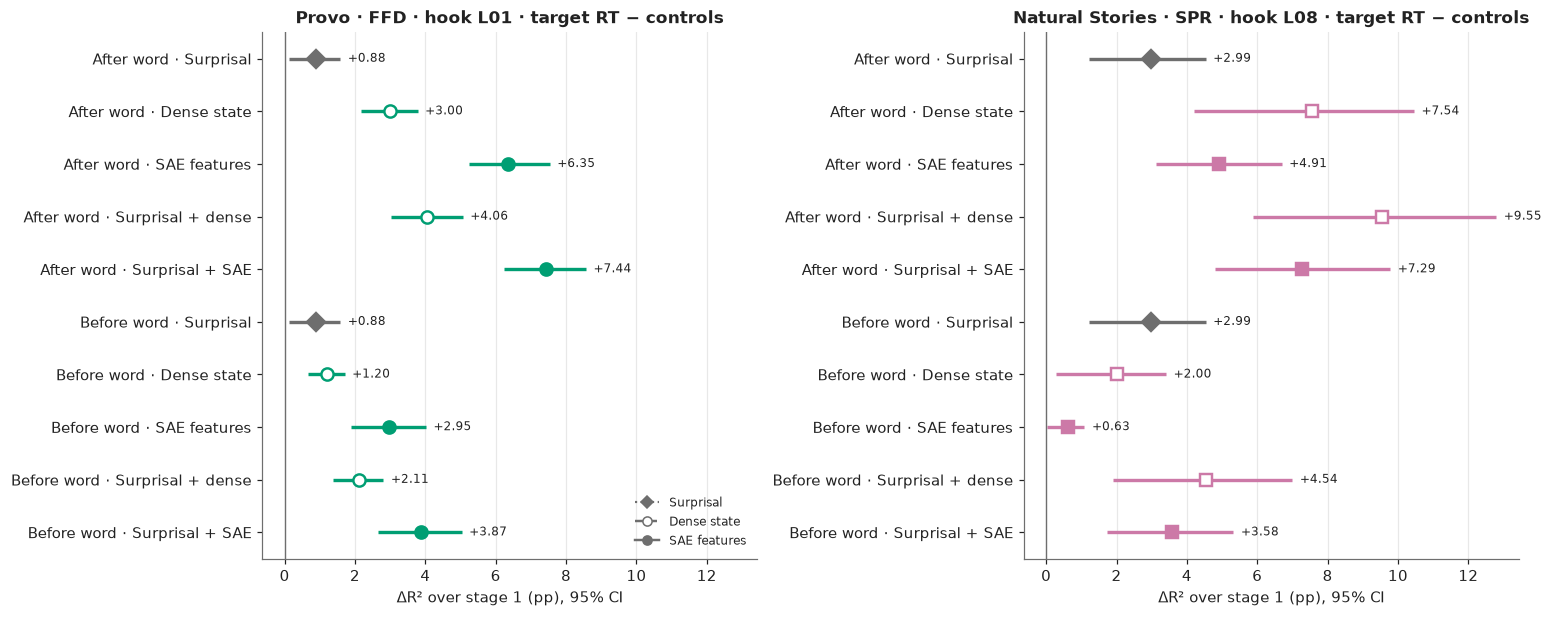

,corpus,kind,representation,delta_r2_pp,ci_low_pp,ci_high_pp,texts_improved,vs_surprisal_pp,vs_surprisal_ci_low_pp,vs_surprisal_ci_high_pp
28,natural_stories,post,dense,7.54,4.20,10.45,9,4.55,1.74,7.07
29,natural_stories,post,sae,4.91,3.12,6.69,10,1.92,0.47,3.61
30,natural_stories,post,surprisal+dense,9.55,5.88,12.79,10,6.55,3.74,8.85
31,natural_stories,post,surprisal+sae,7.29,4.79,9.78,10,4.29,3.01,5.63
80,natural_stories,prefix,dense,2.00,0.28,3.41,8,-0.99,-2.77,0.92
81,natural_stories,prefix,sae,0.63,0.03,1.09,8,-2.36,-3.77,-0.68
82,natural_stories,prefix,surprisal+dense,4.54,1.91,7.00,8,1.55,-0.18,2.91
83,natural_stories,prefix,surprisal+sae,3.58,1.72,5.32,9,0.59,-0.00,0.98
104,natural_stories,-,surprisal,2.99,1.22,4.53,8,NaN,NaN,NaN
157,provo,post,dense,3.00,2.17,3.78,47,2.11,1.01,3.16


In [3]:
order = ["surprisal", "dense", "sae", "surprisal+dense", "surprisal+sae"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), layout="constrained", sharex=True)
p = primary("resid_controls")
for ax, c in zip(axes, CORPORA):
    rows = []
    for k in ["post", "prefix"]:
        for rep in order:
            q = p[(p.corpus == c) & (p.representation == rep) & ((p.kind == k) | (rep == "surprisal"))]
            if len(q):
                r = q.iloc[0]
                rows.append(dict(label=f"{STATE_LABELS[k]} · {REP_LABELS[rep]}", corpus=c, rep=rep,
                                 est=r.delta_r2_pp, lo=r.ci_low_pp, hi=r.ci_high_pp))
    forest(ax, rows, xlabel="ΔR² over stage 1 (pp), 95% CI")
    ax.set_title(f"{CORPUS_LABELS[c]} · hook {PRIMARY_HOOKS[c]} · target RT − controls")
rep_legend(axes[0], ("surprisal", "dense", "sae"), loc="lower right", fontsize=8)
save_figure(fig, FIG, "04_rtprime_controls"); plt.show()
cols = ["corpus", "kind", "representation", "delta_r2_pp", "ci_low_pp", "ci_high_pp", "texts_improved", "vs_surprisal_pp",
        "vs_surprisal_ci_low_pp", "vs_surprisal_ci_high_pp"]
p[[c for c in cols if c in p.columns]].round(2)

# Does the conservative two-stage estimate shrink the gains?

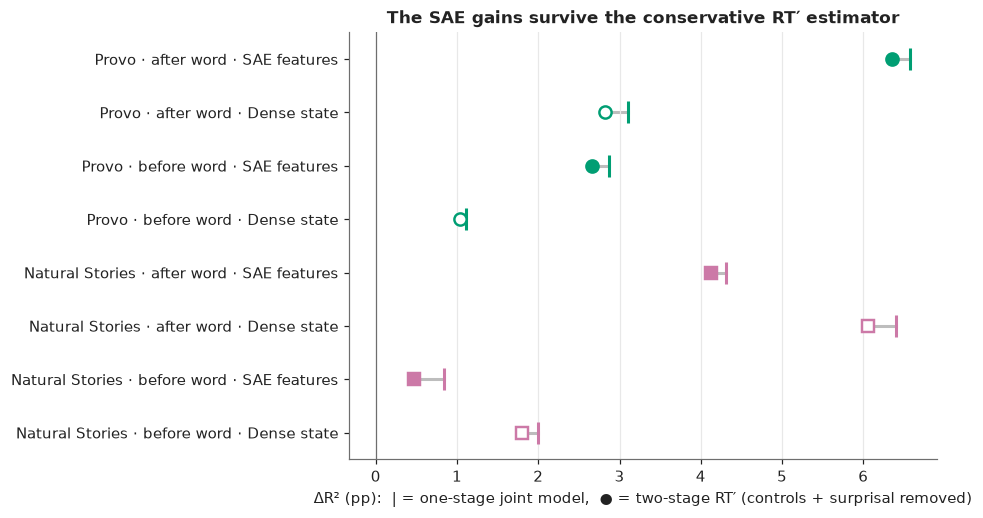

,corpus,kind,rep,one,one_lo,one_hi,two,two_lo,two_hi
0,provo,post,sae,6.58,5.42,7.78,6.35,5.24,7.51
1,provo,post,dense,3.11,2.45,3.76,2.82,2.09,3.47
2,provo,prefix,sae,2.87,1.77,3.98,2.66,1.52,3.78
3,provo,prefix,dense,1.12,0.60,1.62,1.03,0.55,1.50
4,natural_stories,post,sae,4.30,2.97,5.58,4.12,2.58,5.57
5,natural_stories,post,dense,6.40,3.46,8.78,6.06,3.16,8.45
6,natural_stories,prefix,sae,0.84,0.19,1.46,0.47,-0.28,1.09
7,natural_stories,prefix,dense,1.99,0.25,3.37,1.80,-0.11,3.28


In [4]:
from sae_regression_diagnostics import paired_score
q = primary("resid_controls_surprisal")
rows = []
for c in CORPORA:
    for k in ["post", "prefix"]:
        for rep in ["sae", "dense"]:
            f = P["regression"] / c / k / PRIMARY_HOOKS[c] / rep / "predictions.csv"
            one = paired_score(pd.read_csv(f), bootstrap=B, seed=SEED)
            two = q[(q.corpus == c) & (q.kind == k) & (q.representation == rep)].iloc[0]
            rows.append(dict(corpus=c, kind=k, rep=rep, one=100 * one["delta_r2"], one_lo=100 * one["ci_low"],
                             one_hi=100 * one["ci_high"], two=two.delta_r2_pp, two_lo=two.ci_low_pp, two_hi=two.ci_high_pp))
cmp_ = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(8.5, 4.6), layout="constrained")
for i, r in enumerate(cmp_.itertuples()):
    s = rep_style(r.rep, r.corpus)
    ax.plot([r.one, r.two], [i, i], color=LIGHT, lw=2, zorder=1)
    ax.plot(r.one, i, marker="|", color=s["color"], ms=14, mew=2)
    ax.plot(r.two, i, marker=s["marker"], color=s["color"], mfc=s["mfc"], ms=8, mew=1.6)
ax.set_yticks(range(len(cmp_)), [f"{CORPUS_LABELS[r.corpus].split(' ·')[0]} · {STATE_LABELS[r.kind].lower()} · {REP_LABELS[r.rep]}"
                                 for r in cmp_.itertuples()])
ax.set_ylim(len(cmp_) - 0.5, -0.5); ax.axvline(0, color=MUTED, lw=0.8); ax.grid(axis="x", color=GRID)
ax.set_xlabel("ΔR² (pp):  | = one-stage joint model,  ● = two-stage RT′ (controls + surprisal removed)")
ax.set_title("The SAE gains survive the conservative RT′ estimator")
save_figure(fig, FIG, "04_one_vs_two_stage"); plt.show()
cmp_.round(2)

# RT′ layer profile (controls + surprisal removed)

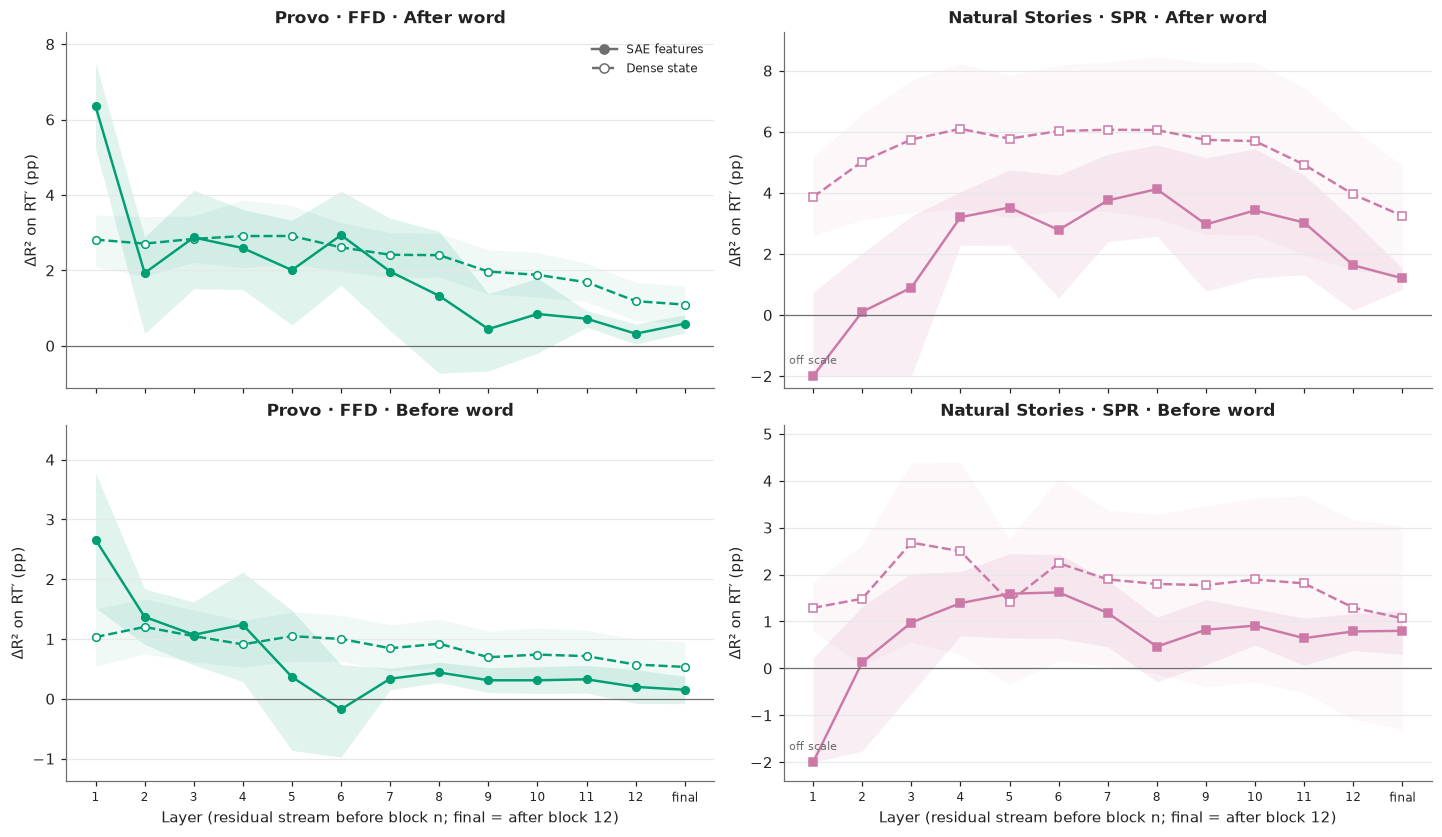

In [5]:
t = res[res.target == "resid_controls_surprisal"].rename(columns={"representation": "rep", "delta_r2_pp": "est",
                                                                  "ci_low_pp": "lo", "ci_high_pp": "hi"})
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5), layout="constrained", sharex=True)
for j, c in enumerate(CORPORA):
    for i, k in enumerate(["post", "prefix"]):
        f = t[(t.corpus == c) & (t.kind == k)]
        layer_profile(axes[i, j], f[["label", "rep", "est", "lo", "hi"]], c, clip=(-2.0, f.hi.max() + 0.5))
        axes[i, j].set_ylim(max(-2.0, f.lo.min()) - 0.4, f.hi.max() + 0.8)
        axes[i, j].set_title(f"{CORPUS_LABELS[c]} · {STATE_LABELS[k]}")
        axes[i, j].set_ylabel("ΔR² on RT′ (pp)")
for ax in axes[0]:
    ax.set_xlabel("")
rep_legend(axes[0, 0], ("sae", "dense"), fontsize=8)
save_figure(fig, FIG, "04_rtprime_layer_profile"); plt.show()